In [ ]:
!pip install pandas
!pip install shap
!pip install xgboost scikit-learn pandas
!pip install lime
!pip install ipython==7.23.1

In [1]:
import pandas as pd

data = pd.read_csv(r"C:\Users\savan\Desktop\Magisterka\ED\projekt\data_removed.csv")
data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,thalch,exang,oldpeak,slope,num
0,1,1.005734,1,0,3,0.702043,-0.251620,1,0.521287,0,1.338488,0,0
1,2,1.429712,1,0,0,1.529743,0.774164,0,-1.126870,1,0.584283,1,2
2,3,1.429712,1,0,0,-0.677456,-0.329038,0,-0.302791,1,1.621315,1,1
3,4,-1.750123,1,0,2,-0.125656,0.077405,0,1.973235,0,2.469795,0,0
4,5,-1.326145,0,0,1,-0.125656,-0.812898,0,1.384608,0,0.490007,2,0


ROC AUC (OvR): 0.8632473812078466
Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        82
           1       0.55      0.68      0.61        53
           2       0.35      0.32      0.33        22
           3       0.50      0.24      0.32        21
           4       1.00      0.17      0.29         6

    accuracy                           0.64       184
   macro avg       0.64      0.45      0.47       184
weighted avg       0.64      0.64      0.62       184



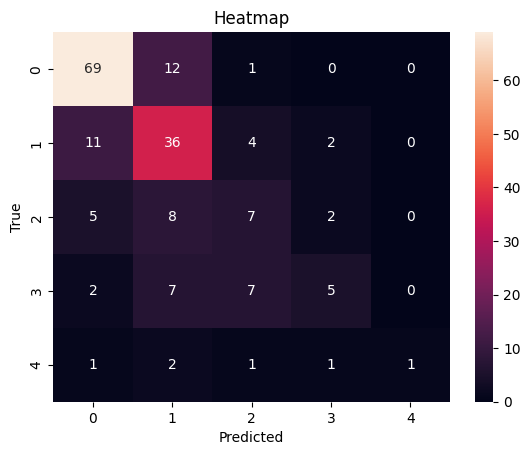

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import seaborn as sns 

y = data['num']
X = data.drop(columns=['num', 'id'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)
random_forest_model_probs = random_forest_model.predict_proba(X_test)

random_forest_model_auc_ovr = roc_auc_score(y_test, random_forest_model_probs, multi_class="ovr", average="macro")
print("ROC AUC (OvR):", random_forest_model_auc_ovr)

random_forest_model_y_pred = random_forest_model.predict(X_test)
print(f'Report:\n{classification_report(y_test, random_forest_model_y_pred)}')
sns.heatmap(confusion_matrix(y_test, random_forest_model_y_pred), annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Heatmap")
plt.show()

Variable Importance Plot - Global Interpretation


C:\Users\savan\AppData\Local\Temp\ipykernel_20572\3652024264.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)
C:\Users\savan\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\savan\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warnin

<Figure size 640x480 with 0 Axes>

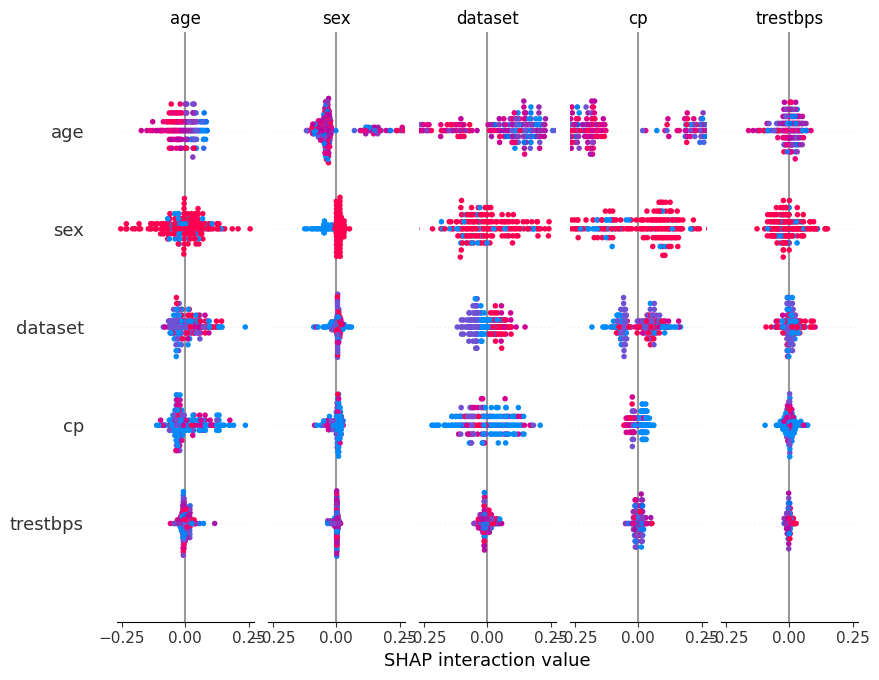

In [64]:
#------------------------------------------------- SHAP ------------------------------------------------
import shap
import matplotlib.pyplot as plt
import math

shap.initjs()

explainer = shap.Explainer(random_forest_model)
shap_values = explainer.shap_values(X_test)

print("Variable Importance Plot - Global Interpretation")
figure = plt.figure()
shap.summary_plot(shap_values, X_test)   

In [56]:
explainer = shap.Explainer(random_forest_model.predict, X_test)
shap_values = explainer(X_train)

PermutationExplainer explainer: 734it [04:28,  2.63it/s]                                                               


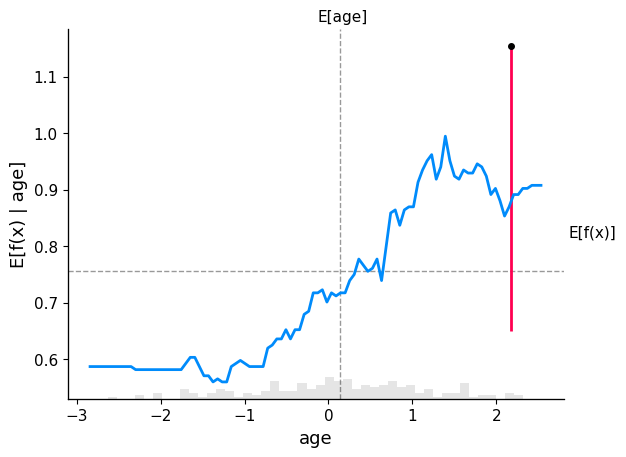

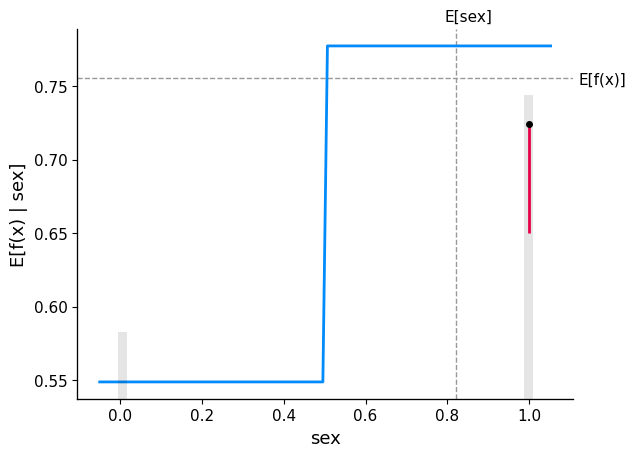

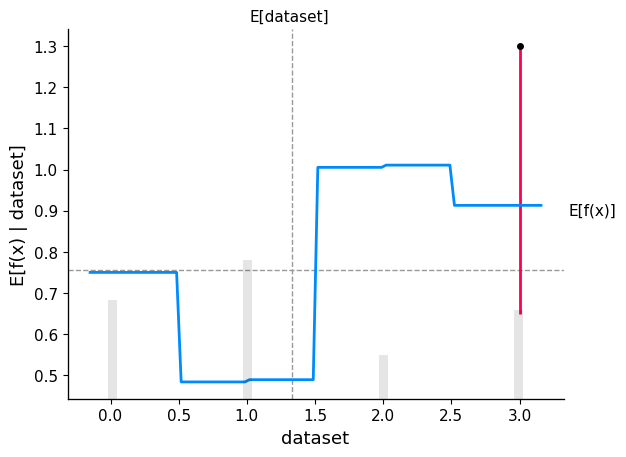

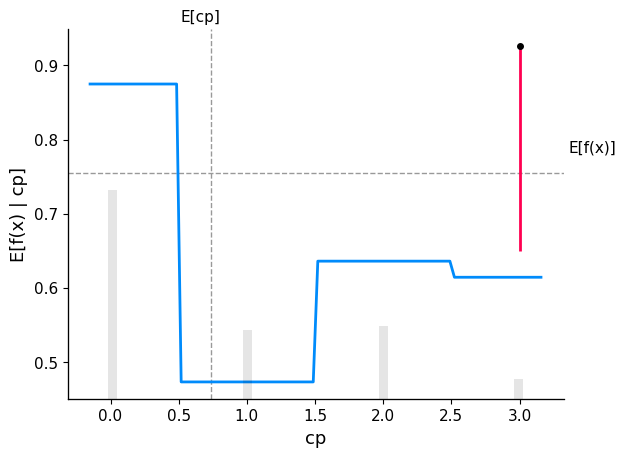

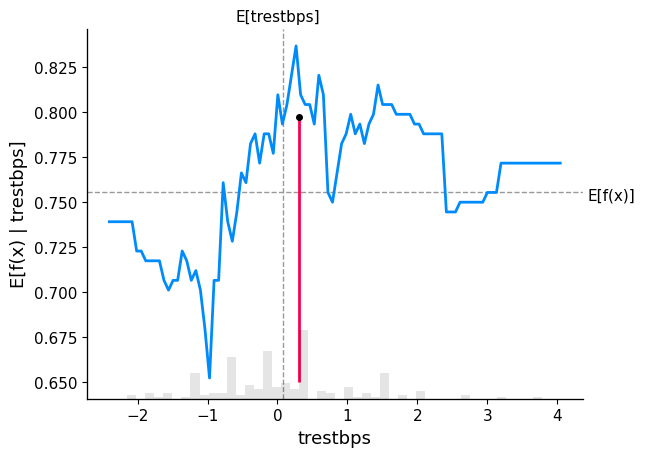

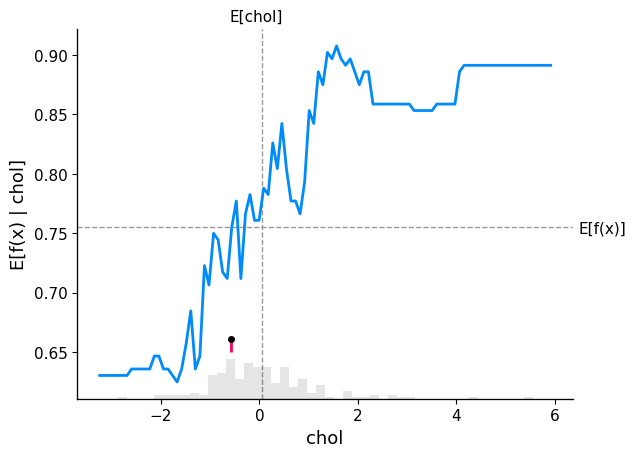

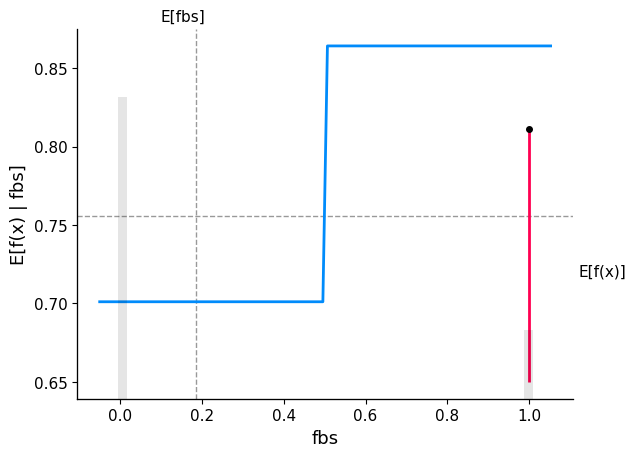

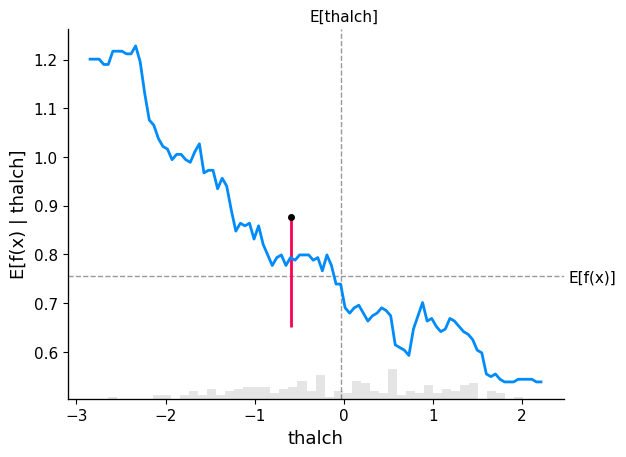

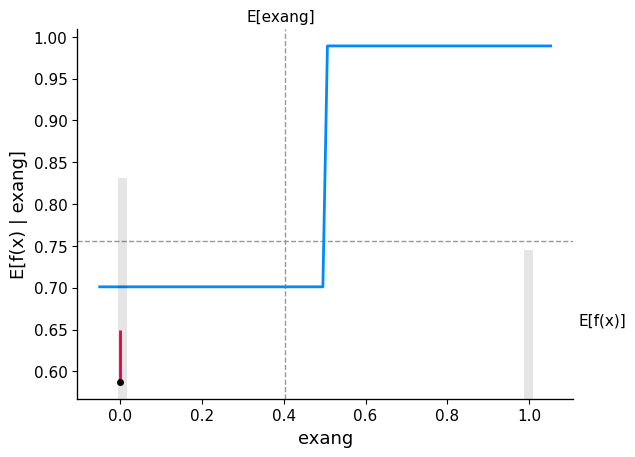

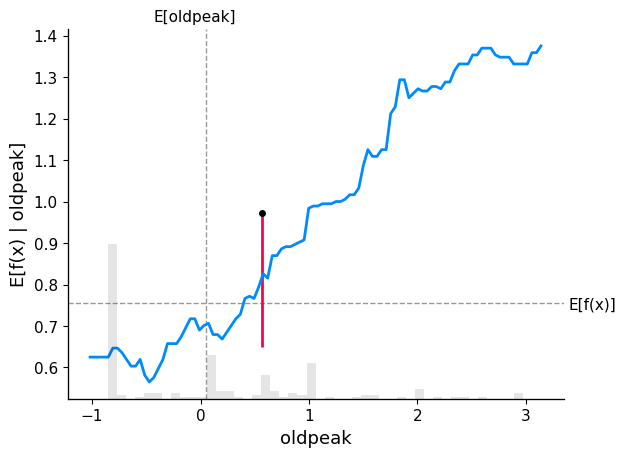

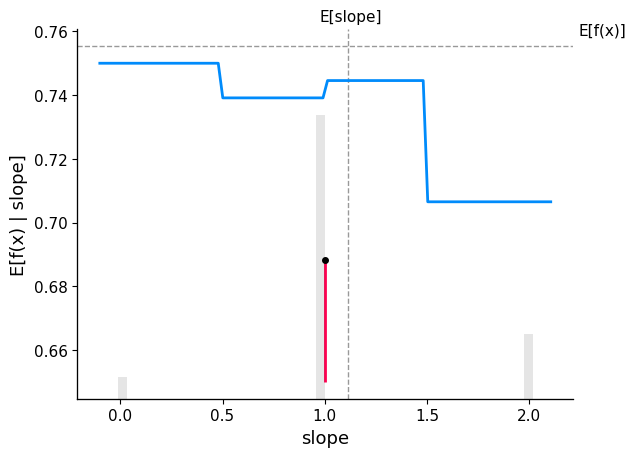

In [51]:
for i, feature in enumerate(X_test.columns):
    shap.partial_dependence_plot(
        feature,
        random_forest_model.predict,
        X_test,
        ice=False,
        model_expected_value=True,
        feature_expected_value=True,
        show=False,
        shap_values=shap_values[sample_ind: sample_ind + 1, :]
    )

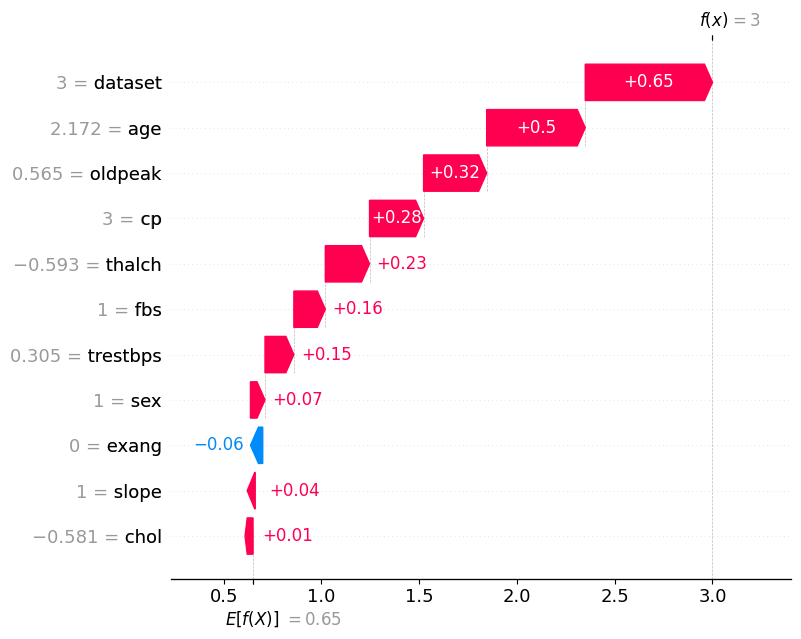

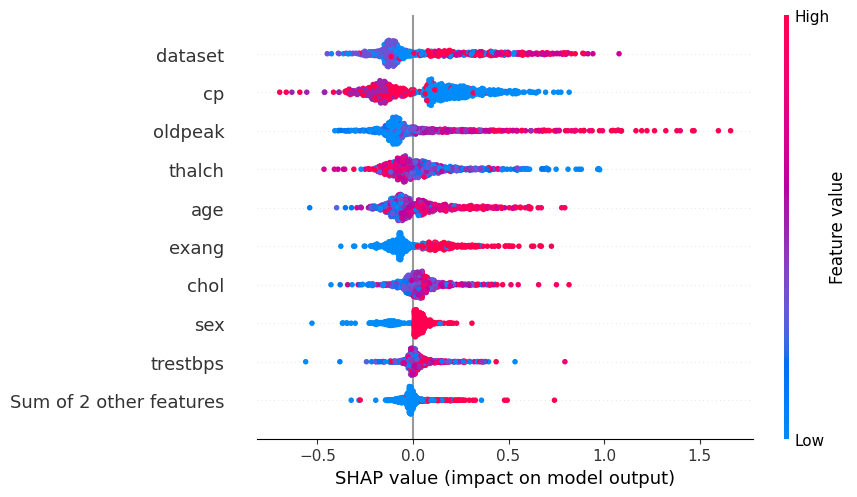

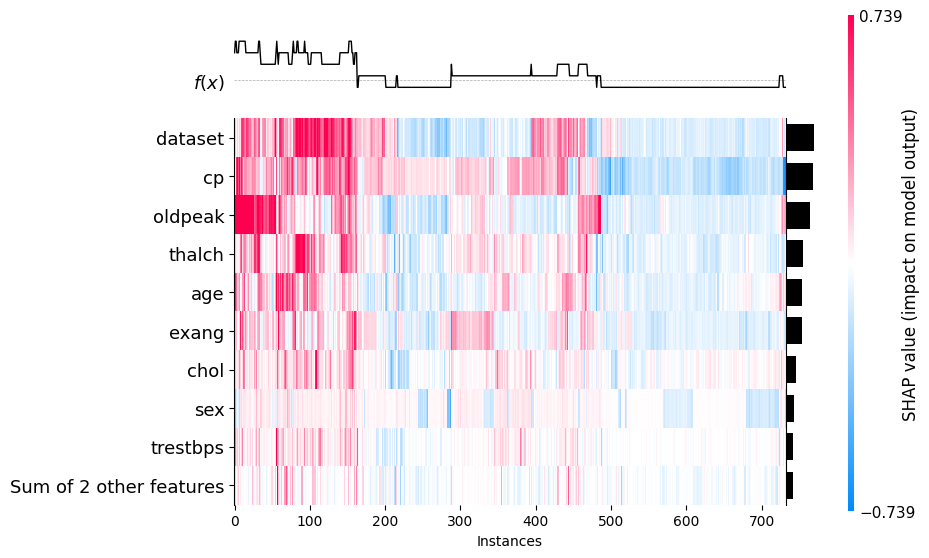

<Axes: xlabel='Instances'>

In [55]:
# the waterfall_plot shows how we get from shap_values.base_values to model.predict(X)[sample_ind]
shap.plots.waterfall(shap_values[sample_ind], max_display=14)

# the beeswarm plot displays SHAP values for each feature across all examples,
# with colors indicating how the SHAP values correlate with feature values
shap.plots.beeswarm(shap_values)

shap.plots.heatmap(shap_values[:1000])

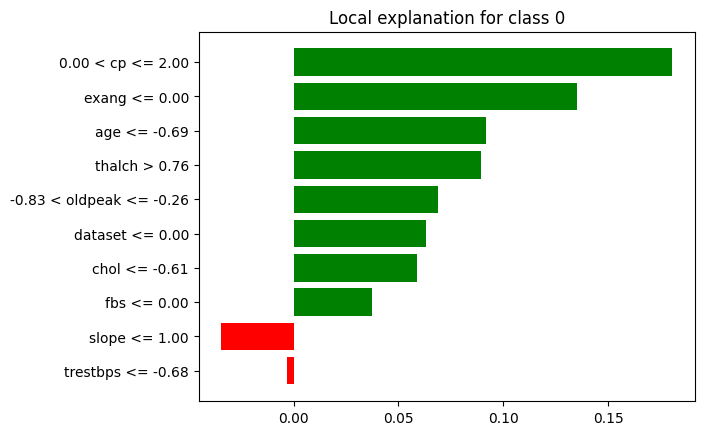

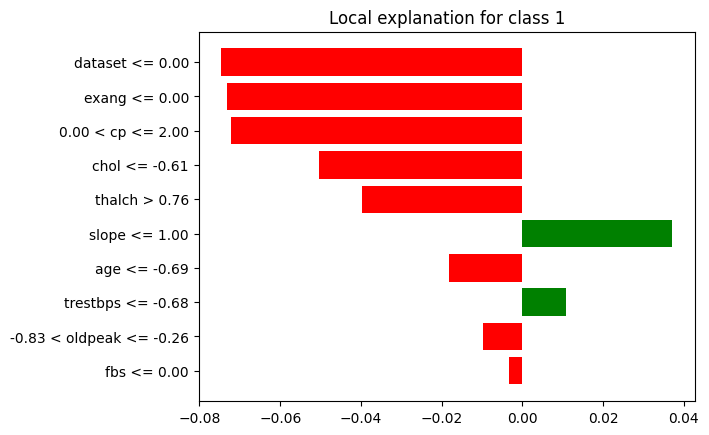

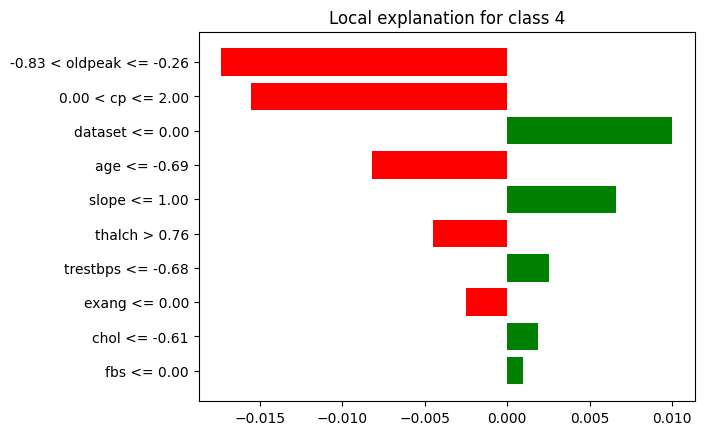

In [6]:
#------------------------------------------------- LIME ------------------------------------------------
from lime.lime_tabular import LimeTabularExplainer

feature_names = list(X_train.columns)
class_names = ['0', '1', '2', '3', '4']

explainer_lime = LimeTabularExplainer(
    X_train.values,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification'
)

def predict_fn(x):
    x_df = pd.DataFrame(x, columns=feature_names)
    return random_forest_model.predict_proba(x_df)

exp_lime = explainer_lime.explain_instance(
    X_test.iloc[120].values,
    predict_fn,
    top_labels = 3
)

for label in exp_lime.top_labels:
    exp_lime.as_pyplot_figure(label=label)
    plt.show()

print("\n\n")
exp_lime.show_in_notebook()
print("\n\n")

dataset 0.078 +/- 0.022
cp      0.059 +/- 0.015
oldpeak 0.042 +/- 0.019
exang   0.041 +/- 0.018


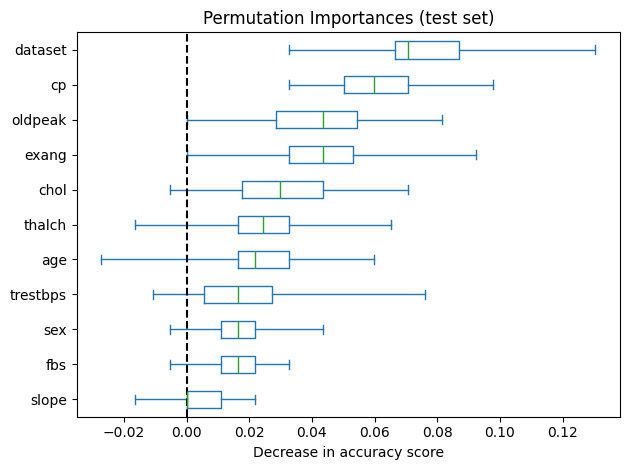

In [78]:
#------------------------------------------------- PFI ------------------------------------------------
from sklearn.inspection import permutation_importance

pfi = permutation_importance(random_forest_model, X_test, y_test, n_repeats = 30, random_state = 42, n_jobs=2)

for i in pfi.importances_mean.argsort()[::-1]:
    if pfi.importances_mean[i] - 2 * pfi.importances_std[i] > 0:
        print(f"{X_test.columns[i]:<8}"
              f"{pfi.importances_mean[i]:.3f}"
              f" +/- {pfi.importances_std[i]:.3f}")

sorted_importances_idx = pfi.importances_mean.argsort()
importances = pd.DataFrame(
    pfi.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()